In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px


ModuleNotFoundError: No module named 'plotly'

# Data Visualization for round 0

We visualize the data using correlation, information theory techniques, time series analysis to understand the best strategy to approach the IMC prosperity 4 trading challenge

In [5]:
df = pd.read_csv(r'C:\Users\fogat\Desktop\imc_trading\imc_trading\TUTORIAL_ROUND_1\prices_round_0_day_-2.csv') 

# 1. STANDARDIZE COLUMNS: Strip hidden whitespace and make everything lowercase
# This fixes issues like ' timestamp ' or 'Timestamp'
df.columns = df.columns.str.strip().str.lower()

# 2. FIX INDEX TRAP: If the index is named 'timestamp', move it to a regular column
# This fixes the issue if your data loader automatically set the first column as the index
if df.index.name and df.index.name.strip().lower() == 'timestamp':
    df = df.reset_index()

# 3. VERIFY AND PROCEED: Safely check if the fix worked
if 'timestamp' not in df.columns:
    print("CRITICAL ERROR: 'timestamp' is still missing. Here is what Pandas sees:")
    print(df.columns.tolist())
    print("\nFirst few rows:")
    print(df.head(2))
    
    # Optional: If you see the column is named something else, rename it here:
    # df = df.rename(columns={'actual_column_name': 'timestamp'})
else:
    print("SUCCESS: 'timestamp' column is ready to use!")
    # Your failing code can now run safely below
    # print(df['timestamp'])
import pandas as pd

# Add the sep=';' parameter to correctly split the columns
df  = pd.read_csv(r'C:\Users\fogat\Desktop\imc_trading\imc_trading\TUTORIAL_ROUND_1\prices_round_0_day_-2.csv', sep=';')

# Now Pandas will parse the columns individually, and this will work:
print(df['timestamp'].head())


CRITICAL ERROR: 'timestamp' is still missing. Here is what Pandas sees:
['day;timestamp;product;bid_price_1;bid_volume_1;bid_price_2;bid_volume_2;bid_price_3;bid_volume_3;ask_price_1;ask_volume_1;ask_price_2;ask_volume_2;ask_price_3;ask_volume_3;mid_price;profit_and_loss']

First few rows:
  day;timestamp;product;bid_price_1;bid_volume_1;bid_price_2;bid_volume_2;bid_price_3;bid_volume_3;ask_price_1;ask_volume_1;ask_price_2;ask_volume_2;ask_price_3;ask_volume_3;mid_price;profit_and_loss
0  -2;0;EMERALDS;9992;11;9990;25;;;10008;11;10010...                                                                                                                                                   
1  -2;0;TOMATOES;4993;7;4992;17;;;5007;7;5008;17;...                                                                                                                                                   
0      0
1      0
2    100
3    100
4    200
Name: timestamp, dtype: int64


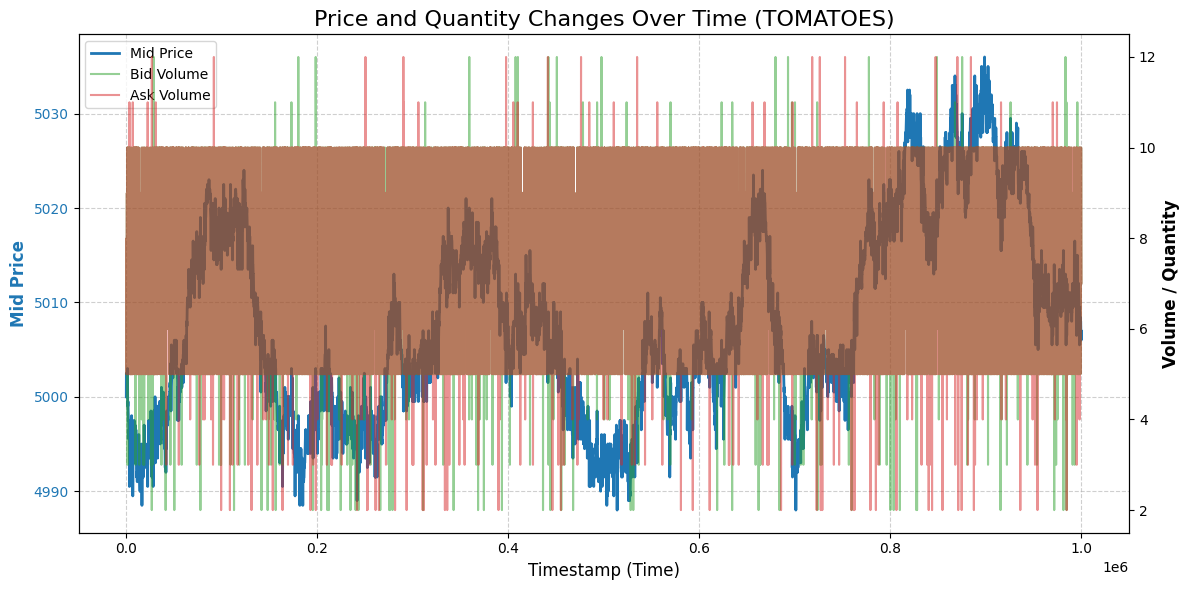

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter for a specific product so the lines connect correctly
product_name = 'TOMATOES'
df_filtered = df[df['product'] == product_name].copy()

# Sort chronologically just to be safe
df_filtered = df_filtered.sort_values(by=['day', 'timestamp'])

# 2. Set up the figure and the primary axis (for Price)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the Mid Price on the left Y-axis
color_price = 'tab:blue'
ax1.set_xlabel('Timestamp (Time)', fontsize=12)
ax1.set_ylabel('Mid Price', color=color_price, fontsize=12, fontweight='bold')
ax1.plot(df_filtered['timestamp'], df_filtered['mid_price'], color=color_price, linewidth=2, label='Mid Price')
ax1.tick_params(axis='y', labelcolor=color_price)

# 3. Create a secondary axis sharing the same X-axis (for Quantity/Volume)
ax2 = ax1.twinx()  

# Plot Bid and Ask volumes on the right Y-axis
color_bid = 'tab:green'
color_ask = 'tab:red'
ax2.set_ylabel('Volume / Quantity', color='black', fontsize=12, fontweight='bold')

# Using alpha=0.5 makes the volume lines slightly transparent so they don't overpower the price line
ax2.plot(df_filtered['timestamp'], df_filtered['bid_volume_1'], color=color_bid, alpha=0.5, label='Bid Volume')
ax2.plot(df_filtered['timestamp'], df_filtered['ask_volume_1'], color=color_ask, alpha=0.5, label='Ask Volume')
ax2.tick_params(axis='y', labelcolor='black')

# 4. Add formatting and legends
plt.title(f'Price and Quantity Changes Over Time ({product_name})', fontsize=16)
fig.tight_layout() # Ensures labels don't get cut off

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Add a subtle grid to the background
ax1.grid(True, linestyle='--', alpha=0.6)

# Display the graph
plt.show()


In [1]:
import pandas as pd
import plotly.express as px

# 1. Load the dataset (remembering to use the semicolon separator!)
df = pd.read_csv(r'C:\Users\fogat\Desktop\imc_trading\imc_trading\TUTORIAL_ROUND_1\prices_round_0_day_-2.csv', sep=';')

# 2. Filter the data specifically for TOMATOES and sort it chronologically
df_tomatoes = df[df['product'] == 'TOMATOES'].copy()
df_tomatoes = df_tomatoes.sort_values(by=['day', 'timestamp'])

# 3. Create the interactive line chart
# By passing a list to 'y', Plotly automatically plots all three lines on the same axis
fig = px.line(
    df_tomatoes, 
    x='timestamp', 
    y=['bid_price_1', 'mid_price', 'ask_price_1'],
    title='TOMATOES: Bid, Mid, and Ask Prices Over Time',
    labels={
        'timestamp': 'Timestamp',
        'value': 'Price',        # Plotly renames the Y-axis to 'value' when plotting multiple columns
        'variable': 'Price Type' # Plotly renames the legend header to 'variable'
    },
    color_discrete_map={
        'bid_price_1': '#00CC96',  # Green for Bid
        'mid_price': '#636EFA',    # Blue for Mid
        'ask_price_1': '#EF553B'   # Red for Ask
    }
)

# 4. Enhance the layout for a better user experience
fig.update_layout(
    hovermode='x unified',  # Shows a clean tooltip with all three prices when you hover over the chart
    template='plotly_white' # Gives the chart a clean, modern background
)

# 5. Display the graph
fig.show()


In [4]:
import pandas as pd
import plotly.graph_objects as go

df_tomatoes = df[df['product'] == 'TOMATOES'].copy()

# Sort chronologically to ensure accurate Open and Close prices
df_tomatoes = df_tomatoes.sort_values(by=['day', 'timestamp'])

# 2. Convert snapshot data into OHLC (Open, High, Low, Close) format
# Since 'timestamp' is an integer, we group it into windows (e.g., every 500 or 1000 units).
# You can adjust 'window_size' depending on how wide you want your candles.
window_size = 500 
df_tomatoes['time_bin'] = (df_tomatoes['timestamp'] // window_size) * window_size

# Calculate Open, High, Low, and Close for the 'mid_price' within each bin
ohlc_df = df_tomatoes.groupby(['day', 'time_bin'])['mid_price'].agg(
    Open='first',
    High='max',
    Low='min',
    Close='last'
).reset_index()

# Create a clean X-axis label combining the Day and the Time Bin
ohlc_df['time_label'] = 'Day ' + ohlc_df['day'].astype(str) + ' : ' + ohlc_df['time_bin'].astype(str)

# 3. Create the Candlestick chart using Plotly Graph Objects
fig = go.Figure(data=[go.Candlestick(
    x=ohlc_df['time_label'],
    open=ohlc_df['Open'],
    high=ohlc_df['High'],
    low=ohlc_df['Low'],
    close=ohlc_df['Close'],
    increasing_line_color='#00CC96',  # Bright green for bullish (price went up)
    decreasing_line_color='#EF553B'   # Bright red for bearish (price went down)
)])

# 4. Enhance the layout
fig.update_layout(
    title='TOMATOES: OHLC Candlestick Chart (Mid Price)',
    xaxis_title='Time Period',
    yaxis_title='Mid Price',
    template='plotly_white',
    xaxis_rangeslider_visible=True  # Keeps the interactive range slider at the bottom
)

# 5. Display the graph
fig.show()

